# Rezagos distribuidos: transformacion de Koyck

## Objetivos
- Estimar la persistencia del consumo mediante `Consumption_(t-1)`.
- Interpretar el efecto contemporaneo de `Production` y su multiplicador de largo plazo.
- Evaluar validation y test con pronosticos recursivos de origen fijo y un benchmark estacional.

## Datos y alcance
La serie horaria tiene `Consumption` como objetivo y `Production` como regresor contemporaneo. El pronostico asume que la produccion futura es conocida; en uso operativo tendria que ser una variable planificada o pronosticada. Train, validation y test se separan en orden cronologico.

In [1]:
# Librerias para el modelo de rezagos distribuidos de Koyck
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [ ]:
# Construimos una ruta reproducible al archivo fuente compartido
from ml_course.data import get_data_path

csv_path = get_data_path("electricity_consumption_and_production.csv", category="external")
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [3]:
# Analisis de variables candidatas para explicar Consumption
# Evaluamos correlacion lineal de cada variable original contra el target.

candidate_cols = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'Consumption'
]

corr_with_target = raw[candidate_cols].corr(numeric_only=True)['Consumption'] \
    .drop('Consumption') \
    .sort_values(key=np.abs, ascending=False)

print('Correlacion (ordenada por magnitud absoluta) con Consumption:')
display(corr_with_target.to_frame('corr_vs_consumption'))

# Breve conclusion automatica de candidatas
strong_candidates = corr_with_target[np.abs(corr_with_target) >= 0.25].index.tolist()
moderate_candidates = corr_with_target[(np.abs(corr_with_target) >= 0.10) & (np.abs(corr_with_target) < 0.25)].index.tolist()

print('Candidatas fuertes (|corr| >= 0.25):', strong_candidates)
print('Candidatas moderadas (0.10 <= |corr| < 0.25):', moderate_candidates)

Correlacion (ordenada por magnitud absoluta) con Consumption:


,corr_vs_consumption
Production,0.690823
Oil and Gas,0.499442
Coal,0.472298
Biomass,0.400475
Hydroelectric,0.358047
Nuclear,0.161838
Wind,0.102026
Solar,-0.048037


Candidatas fuertes (|corr| >= 0.25): ['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric']
Candidatas moderadas (0.10 <= |corr| < 0.25): ['Nuclear', 'Wind']


In [ ]:
# Transformacion de Koyck: Production_t y Consumption_(t-1).
series_df = raw[['Consumption', 'Production']].copy().sort_index()
series_df['Consumption_lag1'] = series_df['Consumption'].shift(1)
series_df = series_df.dropna()

KOYCK_FEATURES = ['Production', 'Consumption_lag1']
TARGET = 'Consumption'

# Split cronologico: train 70%, validation 15%, test 15%.
n_rows = len(series_df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)
train_df = series_df.iloc[:train_end].copy()
val_df = series_df.iloc[train_end:val_end].copy()
test_df = series_df.iloc[val_end:].copy()

X_train, y_train = train_df[KOYCK_FEATURES], train_df[TARGET]

# En un horizonte de varios pasos no se conocen los consumos rezagados futuros.
def recursive_koyck_forecast(model, initial_consumption, future_production):
    previous_consumption = float(initial_consumption)
    predictions = []
    for timestamp, production in future_production.items():
        row = pd.DataFrame(
            {
                'Production': [production],
                'Consumption_lag1': [previous_consumption],
            },
            index=[timestamp],
        )
        prediction = float(model.predict(row[KOYCK_FEATURES])[0])
        predictions.append(prediction)
        previous_consumption = prediction
    return pd.Series(predictions, index=future_production.index, name='Koyck')

# Ajuste con train y pronostico recursivo de validation.
koyck_model = LinearRegression().fit(X_train, y_train)
pred_train = koyck_model.predict(X_train)
pred_val = recursive_koyck_forecast(
    koyck_model,
    train_df[TARGET].iloc[-1],
    val_df['Production'],
)

# Reajuste con train + validation y pronostico recursivo de test.
train_val_df = pd.concat([train_df, val_df])
koyck_final_model = LinearRegression().fit(
    train_val_df[KOYCK_FEATURES],
    train_val_df[TARGET],
)
pred_test = recursive_koyck_forecast(
    koyck_final_model,
    train_val_df[TARGET].iloc[-1],
    test_df['Production'],
)

lambda_hat = koyck_final_model.coef_[KOYCK_FEATURES.index('Consumption_lag1')]
beta_hat = koyck_final_model.coef_[KOYCK_FEATURES.index('Production')]
long_run_multiplier = beta_hat / (1 - lambda_hat) if abs(lambda_hat) < 1 else np.nan

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    if not np.any(nonzero):
        return float('nan')
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def seasonal_naive(history, forecast_index, seasonal_period=24):
    if len(history) < seasonal_period:
        raise ValueError('La historia debe incluir al menos un ciclo diario completo.')
    last_cycle = history.iloc[-seasonal_period:].to_numpy()
    return pd.Series(np.resize(last_cycle, len(forecast_index)), index=forecast_index)

naive_val = seasonal_naive(train_df[TARGET], val_df.index)
naive_test = seasonal_naive(train_val_df[TARGET], test_df.index)

def metric_row(model_name, split_name, actual, forecast):
    return {
        'modelo': model_name,
        'split': split_name,
        'MAE': mean_absolute_error(actual, forecast),
        'RMSE': np.sqrt(mean_squared_error(actual, forecast)),
        'R2': r2_score(actual, forecast),
        'MAPE_%': mape(actual, forecast),
    }

koyck_results = pd.DataFrame([
    metric_row('Koyck', 'train (one-step)', y_train, pred_train),
    metric_row('Koyck', 'validation (recursivo)', val_df[TARGET], pred_val),
    metric_row('Koyck', 'test (recursivo)', test_df[TARGET], pred_test),
]).set_index('split')
forecast_comparison = pd.DataFrame([
    metric_row('Seasonal Naive (24 h)', 'validation', val_df[TARGET], naive_val),
    metric_row('Koyck (recursivo)', 'validation', val_df[TARGET], pred_val),
    metric_row('Seasonal Naive (24 h)', 'test', test_df[TARGET], naive_test),
    metric_row('Koyck (recursivo)', 'test', test_df[TARGET], pred_test),
]).sort_values(['split', 'RMSE']).reset_index(drop=True)

koyck_coefficients = pd.DataFrame({
    'parametro': ['intercepto', 'beta_Production', 'lambda_lag_consumption'],
    'estimacion': [koyck_final_model.intercept_, beta_hat, lambda_hat],
})

print('Variables explicativas:', KOYCK_FEATURES)
print('Coeficientes del modelo reajustado con train + validation:')
display(koyck_coefficients.round(6))
print(f'Multiplicador de largo plazo beta / (1 - lambda): {long_run_multiplier:.6f}')
print('\nMetricas Koyck (train one-step; validation/test recursivos):')
display(koyck_results.round(4))
print('\nComparacion contra Seasonal Naive de 24 horas:')
display(forecast_comparison.round(4))

Variables explicativas: ['Production', 'Consumption_lag1']
Coeficientes estimados:


,parametro,estimacion
0,intercepto,83.181100
1,beta_Production,0.073641
2,lambda_lag_consumption,0.914766


Multiplicador de largo plazo beta / (1 - lambda): 0.863990

Metricas del modelo de Koyck:


,MAE,RMSE,R2,MAPE_%
split,,,,
train,206.9812,278.6203,0.9294,3.1761
validation,235.0345,303.5918,0.9082,3.7400
test,247.7882,325.6511,0.9111,3.9827


In [ ]:
y_test = test_df[TARGET]

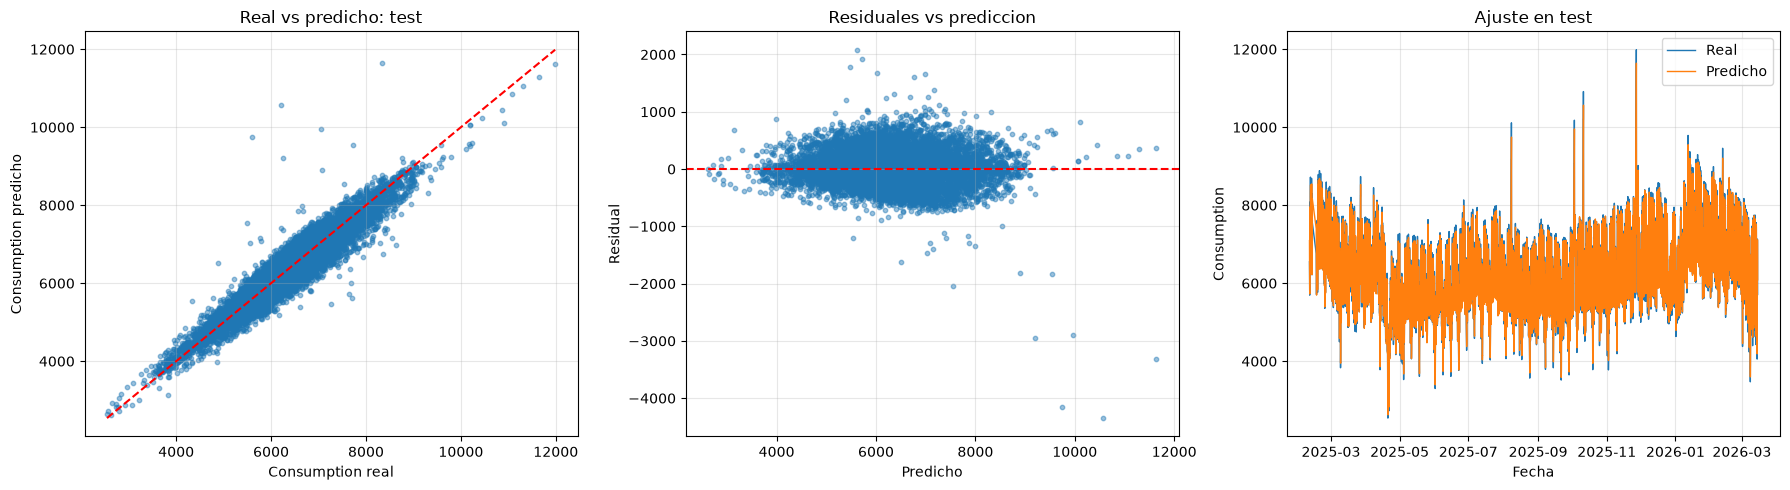

In [4]:
# Diagnostico visual del modelo de Koyck
pred_test_df = pd.DataFrame(index=y_test.index)
pred_test_df['real'] = y_test
pred_test_df['predicho'] = pred_test
pred_test_df['residual'] = pred_test_df['real'] - pred_test_df['predicho']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real frente a predicho
axes[0].scatter(pred_test_df['real'], pred_test_df['predicho'], s=10, alpha=0.45)
min_value = min(pred_test_df['real'].min(), pred_test_df['predicho'].min())
max_value = max(pred_test_df['real'].max(), pred_test_df['predicho'].max())
axes[0].plot([min_value, max_value], [min_value, max_value], 'r--')
axes[0].set_title('Real vs predicho: test')
axes[0].set_xlabel('Consumption real')
axes[0].set_ylabel('Consumption predicho')
axes[0].grid(alpha=0.3)

# Residuales frente a prediccion
axes[1].scatter(pred_test_df['predicho'], pred_test_df['residual'], s=10, alpha=0.45)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuales vs prediccion')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Residual')
axes[1].grid(alpha=0.3)

# Serie observada y predicha en test
axes[2].plot(pred_test_df.index, pred_test_df['real'], label='Real', linewidth=1)
axes[2].plot(pred_test_df.index, pred_test_df['predicho'], label='Predicho', linewidth=1)
axes[2].set_title('Ajuste en test')
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel('Consumption')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretacion del modelo de Koyck

La ecuacion estimada es:

`Consumption_t = intercepto + beta Production_t + lambda Consumption_(t-1) + error_t`

- `lambda` mide la persistencia temporal del consumo; para que el multiplicador de largo plazo sea finito se requiere `abs(lambda) < 1`.
- `beta` representa el efecto contemporaneo de `Production`.
- `beta / (1 - lambda)` aproxima el efecto acumulado de largo plazo de un aumento sostenido de `Production`.
- Train se evalua a un paso con el rezago observado. Validation y test son pronosticos recursivos de origen fijo: cada prediccion pasa a ser el rezago del siguiente paso, sin consumir el consumo real del bloque.

### Efecto temporal de los rezagos: transformacion de Koyck

La transformacion de Koyck implica pesos geometricamente decrecientes:

`efecto_k = beta * lambda^k`

El grafico muestra el efecto asociado a cada rezago horario de `Production` y su efecto acumulado. La linea acumulada se aproxima al multiplicador de largo plazo `beta / (1 - lambda)`.

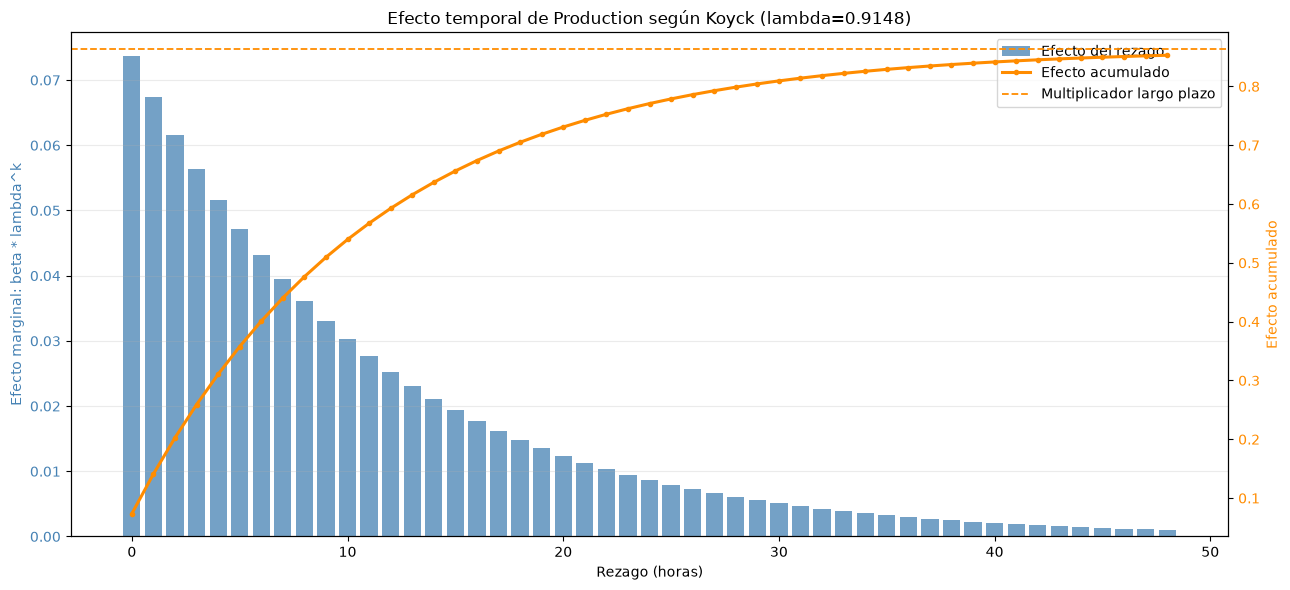

,lag_hours,effect,cumulative_effect
0,0,0.073641,0.073641
1,1,0.067364,0.141005
2,2,0.061623,0.202628
3,3,0.056370,0.258998
4,4,0.051566,0.310564
5,5,0.047171,0.357734
6,6,0.043150,0.400884
7,7,0.039472,0.440357
8,8,0.036108,0.476464
9,9,0.033030,0.509495


In [5]:
# Pesos temporales implicitos de la transformacion de Koyck
if 'beta_hat' not in globals() or 'lambda_hat' not in globals():
    raise NameError("Ejecuta primero el modelo de Koyck para estimar beta_hat y lambda_hat.")

max_lag_hours = 48
lags = np.arange(max_lag_hours + 1)
lag_effects = beta_hat * (lambda_hat ** lags)
cumulative_effects = np.cumsum(lag_effects)

koyck_lag_effects = pd.DataFrame({
    'lag_hours': lags,
    'effect': lag_effects,
    'cumulative_effect': cumulative_effects,
})

fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.bar(
    lags,
    lag_effects,
    color='steelblue',
    alpha=0.75,
    label='Efecto del rezago',
)
ax1.set_xlabel('Rezago (horas)')
ax1.set_ylabel('Efecto marginal: beta * lambda^k', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(axis='y', alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(
    lags,
    cumulative_effects,
    color='darkorange',
    linewidth=2.2,
    marker='o',
    markersize=3,
    label='Efecto acumulado',
)
ax2.axhline(
    long_run_multiplier,
    color='darkorange',
    linestyle='--',
    linewidth=1.3,
    label='Multiplicador largo plazo',
)
ax2.set_ylabel('Efecto acumulado', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

handles_1, labels_1 = ax1.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(handles_1 + handles_2, labels_1 + labels_2, loc='upper right')
ax1.set_title(
    f'Efecto temporal de Production según Koyck '
    f'(lambda={lambda_hat:.4f})'
)

plt.tight_layout()
plt.show()

display(koyck_lag_effects.head(12).round(6))

## Evaluacion, baseline y limites
Compara MAE, RMSE, R2 y MAPE de Koyck con Seasonal Naive de 24 horas en validation; consulta test solo como evaluacion final. El benchmark repite el ultimo ciclo diario y, si el horizonte excede 24 horas, lo repite. La prediccion recursiva mide un horizonte de origen fijo, no una actualizacion horaria con nuevos consumos observados. Tanto Koyck como el benchmark requieren que `Production` futura se conozca o se pronostique.

In [ ]:
# Calculo final del multiplicador y analisis de capacidad predictiva
if 'koyck_final_model' not in globals():
    raise NameError('Ejecuta primero el modelo de Koyck.')

beta_long_run = float(koyck_final_model.coef_[KOYCK_FEATURES.index('Production')])
lambda_long_run = float(koyck_final_model.coef_[KOYCK_FEATURES.index('Consumption_lag1')])
long_run_multiplier_final = (
    beta_long_run / (1 - lambda_long_run)
    if abs(lambda_long_run) < 1
    else np.nan
)

predictive_analysis = koyck_results.copy()
train_split = 'train (one-step)'
validation_split = 'validation (recursivo)'
test_split = 'test (recursivo)'
predictive_analysis['RMSE_vs_train'] = predictive_analysis['RMSE'] / predictive_analysis.loc[train_split, 'RMSE']
predictive_analysis['MAE_vs_train'] = predictive_analysis['MAE'] / predictive_analysis.loc[train_split, 'MAE']

validation_test_rmse_gap = predictive_analysis.loc[test_split, 'RMSE'] - predictive_analysis.loc[validation_split, 'RMSE']
validation_test_r2_gap = predictive_analysis.loc[validation_split, 'R2'] - predictive_analysis.loc[test_split, 'R2']
test_residual_bias = float((y_test.to_numpy() - pred_test).mean())
test_residual_std = float((y_test.to_numpy() - pred_test).std())

print('Multiplicador de largo plazo del modelo reajustado con train + validation:')
print(f'beta_Production = {beta_long_run:.6f}')
print(f'lambda = {lambda_long_run:.6f}')
print(f'beta / (1 - lambda) = {long_run_multiplier_final:.6f}')

print('\nComparacion de capacidad predictiva:')
display(predictive_analysis.round(4))

print('Analisis de generalizacion:')
print(f'- Diferencia RMSE test - validation: {validation_test_rmse_gap:.4f}')
print(f'- Diferencia R2 validation - test: {validation_test_r2_gap:.4f}')
print(f'- Sesgo medio de los residuales en test: {test_residual_bias:.4f}')
print(f'- Desviacion estandar de residuales en test: {test_residual_std:.4f}')

if abs(validation_test_rmse_gap) < 0.10 * predictive_analysis.loc[validation_split, 'RMSE']:
    print('- El desempeno de validation y test es cercano; no se observa una degradacion fuerte fuera de muestra.')
else:
    print('- Existe una diferencia apreciable entre validation y test; conviene revisar estabilidad temporal.')

if abs(test_residual_bias) < 0.05 * predictive_analysis.loc[test_split, 'MAE']:
    print('- El sesgo medio de los residuales es pequeno frente al MAE.')
else:
    print('- El sesgo medio de los residuales merece una revision adicional.')

Calculo del multiplicador de largo plazo:
beta_Production = 0.073641
lambda = 0.914766
beta / (1 - lambda) = 0.863990

Comparacion de capacidad predictiva:


,MAE,RMSE,R2,MAPE_%,RMSE_vs_train,MAE_vs_train
split,,,,,,
train,206.9812,278.6203,0.9294,3.1761,1.0000,1.0000
validation,235.0345,303.5918,0.9082,3.7400,1.0896,1.1355
test,247.7882,325.6511,0.9111,3.9827,1.1688,1.1972


Analisis de generalizacion:
- Diferencia RMSE test - validation: 22.0593
- Diferencia R2 validation - test: -0.0030
- Sesgo medio de los residuales en test: 13.3297
- Desviacion estandar de residuales en test: 325.3782
- El desempeno de validation y test es cercano; no se observa una degradacion fuerte fuera de muestra.
- El sesgo medio de los residuales merece una revision adicional.


## Ejercicios
1. Compara el forecast recursivo con una evaluacion rolling de un paso y explica por que sus errores responden a preguntas distintas.
2. Examina si `abs(lambda) < 1`; describe que implica para la persistencia estimada y el multiplicador de largo plazo.
3. Sustituye `Production` observada por un pronostico de produccion y evalua como cambia el error de test.

## Referencias
- Koyck, L. M. (1954). *Distributed Lags and Investment Analysis*. North-Holland.
- [Statsmodels: Time Series Analysis](https://www.statsmodels.org/stable/tsa.html)